In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statstests.process import stepwise
from scipy.stats import shapiro #teste de Shapiro-Wilk
from scipy import stats #testes estatísticos
from statsmodels.stats.outliers_influence import variance_inflation_factor #diagnóstico de multicolinearidade
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

## Tratamento e limpeza dos dados

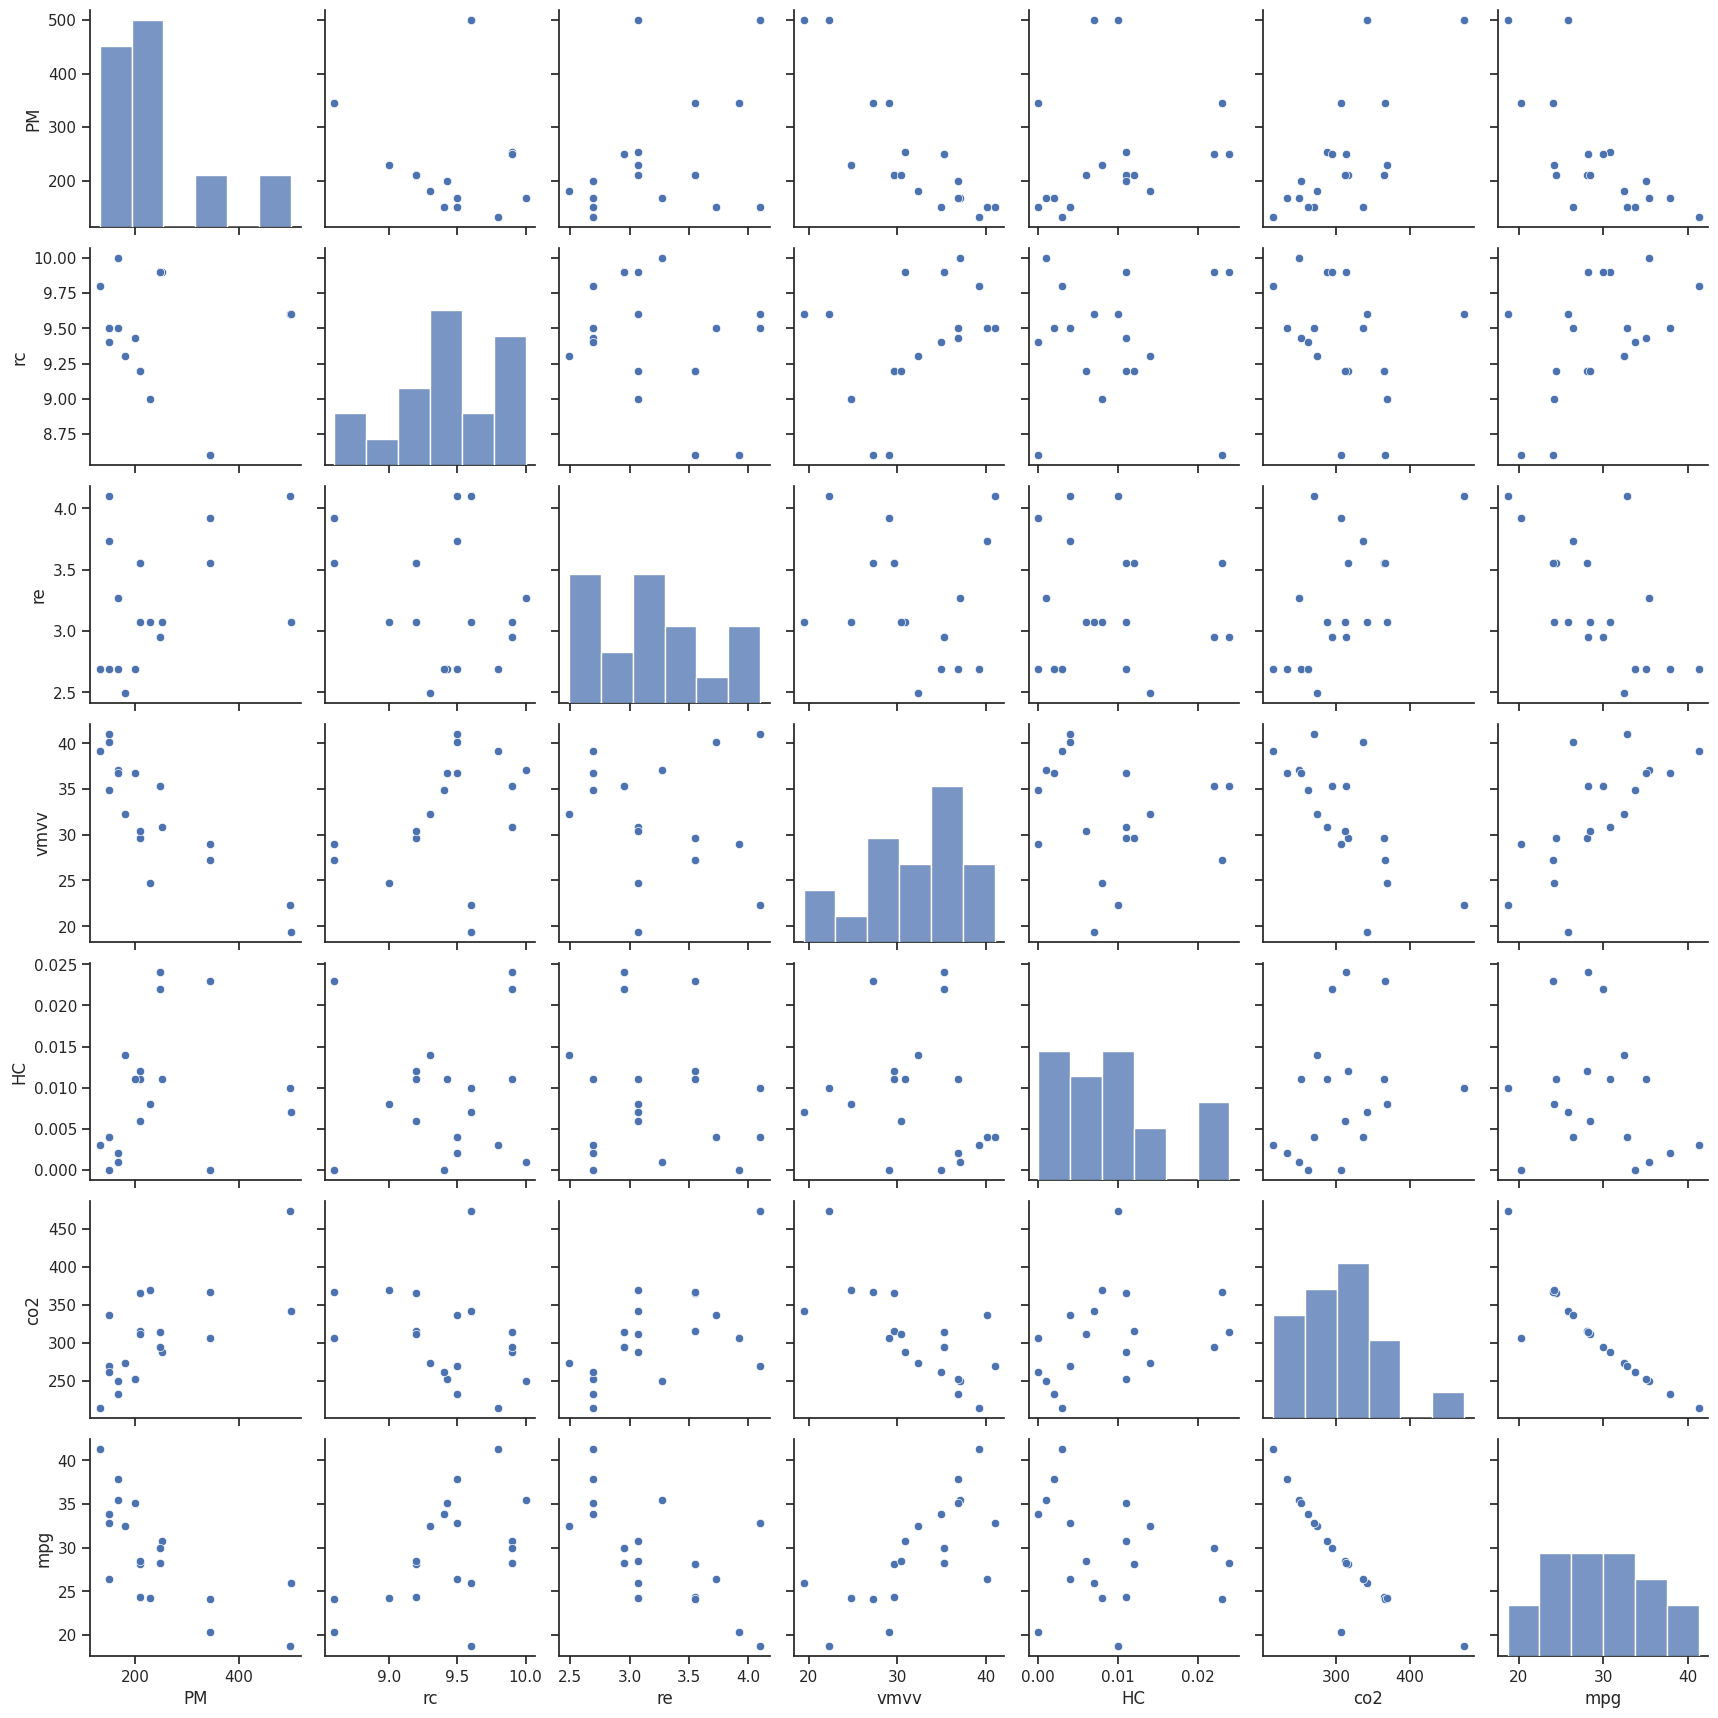

In [2]:
df = pd.read_excel('dataset.xlsx')  

#Retirando todas as linhas o com valor de mpg nulo
df = df.dropna(subset=['mpg'])

#substituir o valor do rc faltante pela média de suas váriaveis
rc_mean = df[df['rc'].notnull()]['rc'].mean()
df.loc[df['rc'].isnull(), 'rc'] = rc_mean

#Substituido um valor de co2 impossivel de ser feito
co2_mean = int(round(df[df['co2'] != 0]['co2'].mean()))
df.loc[df['co2'] == 0, 'co2'] = co2_mean

#Removendo a variavel que queremos medir
df.set_index('Modelo do carro', inplace=True)

tipos_salvos = df['tipo'].copy()

# Colunas nao importantes para a analise que serao removida
colunas_removidas = ['cfab', 'csd', 'tipo']
df = df.drop(columns = colunas_removidas)

# Verificando se as variaveis são correlacionadas

sns.set(style='ticks')
sns.pairplot(df)



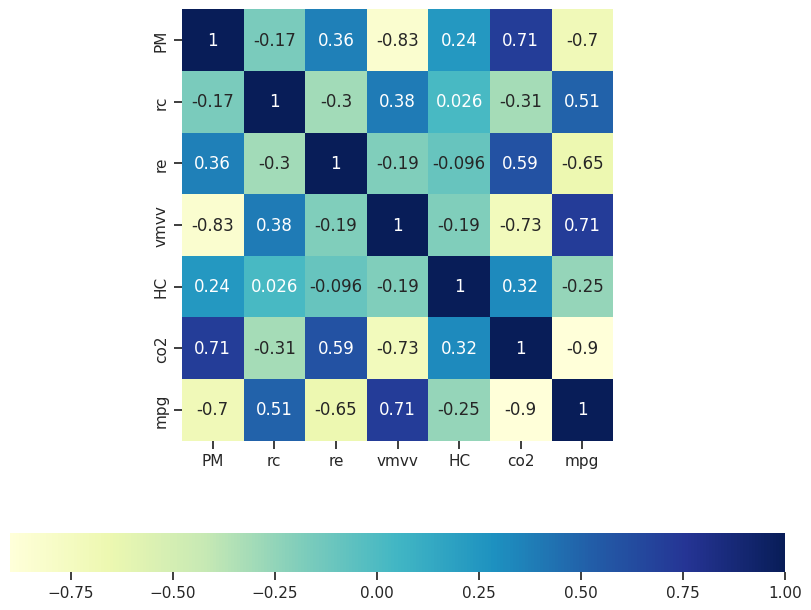

In [3]:
plt.figure(figsize=(10,8))
ax=sns.heatmap(df.corr(),
               annot=True,
               cmap='YlGnBu',
               cbar_kws={"orientation":"horizontal"})
ax.set_aspect("equal")

## Análise de Componentes Principais

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA()
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    pca_result, 
    columns=[f'CP{i+1}' for i in range(pca_result.shape[1])],
    index=df.index # Mantém os nomes dos carros nas linhas!
)

print("Dados prontos e transformados em Componentes Principais:")
print(df_pca.head())

Dados prontos e transformados em Componentes Principais:
                         CP1       CP2       CP3       CP4       CP5  \
Modelo do carro                                                        
300C/SRT-8          0.493311  0.906723  0.586367 -0.512232  0.011180   
CARAVAN 2WD         1.072262  0.951744 -1.253018  0.296094 -0.209391   
CROSSFIRE ROADSTER  2.112763 -0.481034  1.120036 -0.753231  0.023697   
DAKOTA PICKUP 2WD  -0.650396 -0.300904 -0.193521  0.608362  0.038176   
DAKOTA PICKUP 4WD  -1.333002 -0.407614  0.004084  0.670975 -0.633317   

                         CP6       CP7  
Modelo do carro                         
300C/SRT-8          0.050177 -0.400557  
CARAVAN 2WD        -0.043844 -0.002833  
CROSSFIRE ROADSTER  0.132219 -0.227684  
DAKOTA PICKUP 2WD   0.481938 -0.392004  
DAKOTA PICKUP 4WD   0.173644 -0.159037  


In [5]:
print("Explicação da variância por componente principal:")
eigenvalues = pca.explained_variance_
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i in range(len(eigenvalues)):
    print(f"CP{i+1}: Autovalor = {eigenvalues[i]:.3f}, Variância = {explained_variance[i]:.1%}, Acumulada = {cumulative_variance[i]:.1%}")


Explicação da variância por componente principal:
CP1: Autovalor = 4.089, Variância = 55.3%, Acumulada = 55.3%
CP2: Autovalor = 1.273, Variância = 17.2%, Acumulada = 72.6%
CP3: Autovalor = 0.849, Variância = 11.5%, Acumulada = 84.1%
CP4: Autovalor = 0.801, Variância = 10.8%, Acumulada = 94.9%
CP5: Autovalor = 0.233, Variância = 3.1%, Acumulada = 98.1%
CP6: Autovalor = 0.083, Variância = 1.1%, Acumulada = 99.2%
CP7: Autovalor = 0.061, Variância = 0.8%, Acumulada = 100.0%


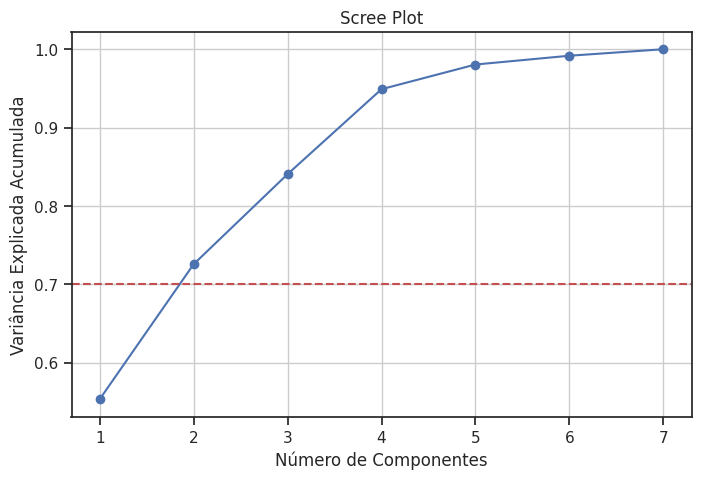

In [6]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative)+1),
         cumulative,
         marker='o')

plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Scree Plot')

plt.axhline(y=0.70, color='r', linestyle='--')
plt.grid(True)

plt.show()

In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'CP{i+1}' for i in range(pca.n_components_)],
    index=df.columns
)

components = loadings.iloc[:, :2]

print(np.round(loadings.iloc[:, :2], 3))

        CP1    CP2
PM   -0.425  0.227
rc    0.250  0.420
re   -0.311 -0.495
vmvv  0.426 -0.185
HC   -0.146  0.694
co2  -0.471  0.056
mpg   0.485  0.091


In [8]:
for component in components.columns:
    print(f"Componente {component}:")
    sorted_loadings = components[component].abs().sort_values(ascending=False)
    for variable in sorted_loadings.index:
        loading_value = components.loc[variable, component]
        if abs(loading_value) > 0.3:  # Considerando apenas loadings significativos
            print(f"  {variable}: {loading_value:.3f}")

Componente CP1:
  mpg: 0.485
  co2: -0.471
  vmvv: 0.426
  PM: -0.425
  re: -0.311
Componente CP2:
  HC: 0.694
  re: -0.495
  rc: 0.420


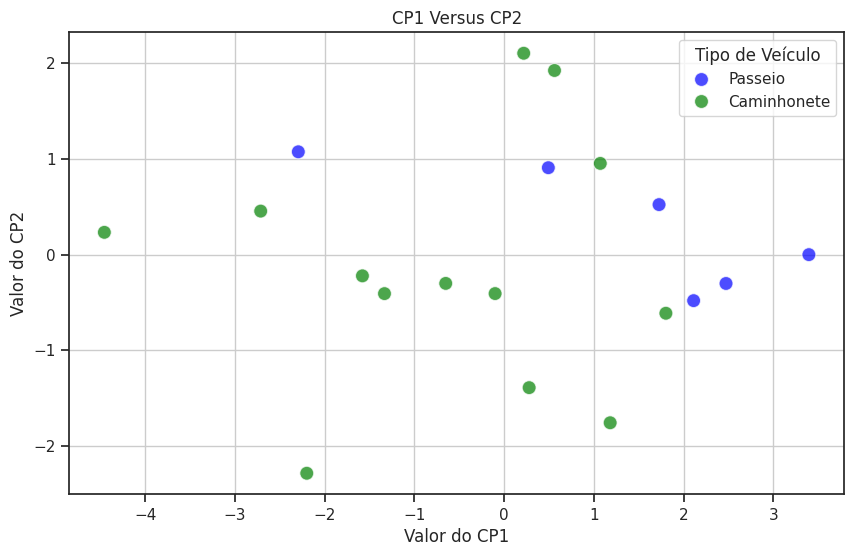

In [9]:
# Cria o DataFrame com as componentes principais
df_final = df_pca[['CP1', 'CP2']].copy()

# 1. Adiciona a coluna salva dando o nome de 'Categoria'
df_final['Categoria'] = tipos_salvos

# 2. Faz o mapeamento usando a coluna 'Categoria' (e não 'tipo'!)
df_final['Categoria'] = df_final['Categoria'].map({'C': 'Passeio', 'T': 'Caminhonete'})


cores_personalizadas = {'Passeio': 'blue', 'Caminhonete': 'green'}

plt.figure(figsize=(10,6))

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_final, 
    x='CP1', 
    y='CP2', 
    hue='Categoria',          
    palette=cores_personalizadas, 
    s=100,                    
    alpha=0.7                 
)

plt.title('CP1 Versus CP2')
plt.xlabel('Valor do CP1')
plt.ylabel('Valor do CP2')
plt.grid(True)
plt.legend(title='Tipo de Veículo', loc='upper right')
plt.show()